<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme de Newton </h1>
</center>

## Implémentation 
 
1. Coder l’algorithme de Newton dans le fichier `src/newton.jl` en respectant la spécification donnée dans ce même fichier ;
2. Exécuter les tests ci-dessous et vérifier qu'ils passent.

Pour les tests, nous avons défini les fonctions suivantes $f_1 \colon \mathbb{R}^3 \to \mathbb{R}$
et $f_2 \colon \mathbb{R}^2 \to \mathbb{R}$.

$$
    f_{1}(x_1, x_2, x_3) = 2 (x_1 +x_2 + x_3 -3)^2 + (x_1-x_2)^2 + (x_2 - x_3)^2
$$
et
$$
    f_{2}(x_1,x_2) = 100(x_2-x_1^2)^2 + (1-x_1)^2.
$$

**Remarque.** On peut retrouver ces fonctions dans le fichier `test/fonctions_de_tests.jl`.

In [1]:
include("../src/newton.jl")         # votre algorithme de Newton
include("../test/tester_newton.jl") # la fonction pour tester votre algorithme de Newton

afficher = false # si true, alors affiche les résultats des algorithmes

tester_newton(newton, afficher); # tester l'algorithme de Newton

Affichage des résultats des algorithmes : false

Test Summary:        | Pass  Total  Time
algorithme de Newton |   19     19  2.6s


## Interprétation

**Remarque.** Vous pouvez mettre `affiche=true` dans les tests de l'algorithme de Newton pour
vous aider.

### 1. Justifier les résultats obtenus pour l'exemple $f_0$ ci-dessous;

La première et la dernière résolution sont réalisées avec un point critique pour point de départ. Il est donc cohérent que l'algorithme converge en une seule itération et que ce soit la CN1 qui soit utilisée.

La seconde résolution converge en 3 itération. C'est encore la CN1 qui arrête l'algorithme. Cela veut dire que l'approximation de $f_0$ à l'ordre 1 est très bonne.

-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = -1.5707963267948966
  * x_sol    = -1.5707963267948966
  * f(x_sol) = -1.0
  * nb_iters = 0
  * flag     = 0
  * solution = -1.5707963267948966
-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = -1.0707963267948966
  * x_sol    = -1.5707963267949088
  * f(x_sol) = -1.0
  * nb_iters = 3
  * flag     = 0
  * solution = -1.5707963267948966
-------------------------------------------------------------------------
Résultats de : Newton appliqué à f0:
  * x0       = 1.5707963267948966
  * x_sol    = 1.5707963267948966
  * f(x_sol) = 1.0
  * nb_iters = 0
  * flag     = 0
  * solution = -1.5707963267948966


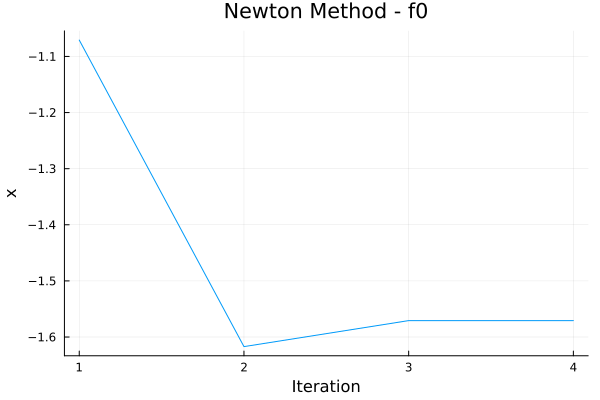

In [2]:
using Plots
include("../src/newton.jl") # votre algorithme de Newton
include("../test/fonctions_de_tests.jl") # pour avoir la fonction d'affichage des résultats

# Fonction f0
# -----------
f0(x)      = sin(x)
grad_f0(x) = cos(x) # la gradient de la fonction f0
hess_f0(x) = -sin(x) # la hessienne de la fonction f0
solution   = -pi / 2

x0 = solution
x_sol, f_sol, flag, nb_iters = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)

x0 = -pi / 2 + 0.5
x_sol, f_sol, flag, nb_iters, xs = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)

x0 = pi / 2
x_sol, f_sol, flag, nb_iters = newton(f0, grad_f0, hess_f0, x0)
afficher_resultats("Newton", "f0", x0, x_sol, f_sol, flag, nb_iters, solution)

# affichage des itérés
plot(xs, title = "Newton Method - f0", xlabel = "Iteration", ylabel = "x", legend = false)


### 2. Justifier que l’algorithme implémenté converge en une itération pour $f_{1}$;

On a

$$
f_{1}(x_1, x_2, x_3) = 2 (x_1 +x_2 + x_3 -3)^2 + (x_1-x_2)^2 + (x_2 - x_3)^2
$$
puis
$$
\nabla f_{1}(x_1, x_2, x_3) = \begin{pmatrix}
    2(2x_1 + 2x_2 + 2x_3 - 6) + 2(x_1 - x_2) \\
    2(2x_1 + 2x_2 + 2x_3 - 6) - 2(x_1 - x_2) + 2(x_2 - x_3) \\
    2(2x_1 + 2x_2 + 2x_3 - 6) - 2(x_2 - x_3)
\end{pmatrix} \\
$$
et
$$
\nabla^2 f_{1}(x_1, x_2, x_3) = \begin{pmatrix}
    6 & -4 & 0 \\
    -4 & 8 & -4 \\
    0 & -4 & 6
\end{pmatrix}
$$

$f_{1}$ est une fonction quadratique, sa matrice hessienne est constante. L'algorithme de Newton converge en une itération pour les fonctions quadratiques puisqu'il utilise une approximation de la fonction à l'ordre 2. Ici, l'approximation est exacte, la solution approchée est donc la solution exacte.

In [3]:
include("../src/newton.jl") # votre algorithme de Newton
include("../test/fonctions_de_tests.jl") # pour avoir la fonction d'affichage des résultats

# Fonction f1
# -----------
f1(x) = 2 * (x[1] + x[2] + x[3] - 3)^2 + (x[1] - x[2])^2 + (x[2] - x[3])^2
grad_f1(x) = [4 * (x[1] + x[2] + x[3] - 3) + 2 * (x[1] - x[2]); # dérivée /x1
	4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[1] - x[2]) + 2 * (x[2] - x[3]); # dérivée /x2
	4 * (x[1] + x[2] + x[3] - 3) - 2 * (x[2] - x[3])] # dérivée /x3
hess_f1(x) = [6 2 4; 2 8 2; 4 2 6]
solution = [1; 1; 1]

x0 = [0; 0; 0]
x_sol, f_sol, flag, nb_iters = newton(f1, grad_f1, hess_f1, x0)
afficher_resultats("Newton", "f1", x0, x_sol, f_sol, flag, nb_iters, solution)

x0 = [10; 10; 10]
x_sol, f_sol, flag, nb_iters = newton(f1, grad_f1, hess_f1, x0)
afficher_resultats("Newton", "f1", x0, x_sol, f_sol, flag, nb_iters, solution)

-------------------------------------------------------------------------
Résultats de : Newton appliqué à f1:
  * x0       = [0, 0, 0]
  * x_sol    = [1.0, 1.0, 0.9999999999999999]
  * f(x_sol) = 1.232595164407831e-32
  * nb_iters = 1
  * flag     = 0
  * solution = [1, 1, 1]
-------------------------------------------------------------------------
Résultats de : Newton appliqué à f1:
  * x0       = [10, 10, 10]
  * x_sol    = [1.0, 1.0, 1.0000000000000018]
  * f(x_sol) = 9.466330862652142e-30
  * nb_iters = 1
  * flag     = 0
  * solution = [1, 1, 1]


### 3. Justifier que l’algorithme puisse ne pas converger pour $f_{2}$ avec certains points initiaux.

On a

$$
f_{2}(x) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2
$$
puis
$$
\nabla f_{2}(x) = \begin{pmatrix}
    -400x_1(x_2 - x_1^2) - 2(1 - x_1) \\
    200(x_2 - x_1^2)
\end{pmatrix}
$$
et
$$
\nabla^2 f_{2}(x) = \begin{pmatrix}
    400(x_2 - 3x_1^2) + 2 & -400x_1 \\
    -400x_1 & 200
\end{pmatrix}
$$

Le déterminant de la hessienne est est

$$
\det\left(\nabla^2 f_{2}(x)\right) = \left|\begin{matrix}
    400(x_2 - 3x_1^2) + 2 & -400x_1 \\
    -400x_1 & 200
\end{matrix}\right| = 800x_1^2 - 1200x_2 + 400
$$

Il existe des points $x$ tels que le déterminant est nul et donc que la matrice hessienne n'est pas inversible (mal conditionnée). L'algorithme de Newton ne converge pas dans ce cas.

Selon les points, $f_2$ peut être localement concave ou localement convexe.

-------------------------------------------------------------------------
Résultats de : Newton appliqué à f2:
  * x0       = [0.0, 0.3333333333333333]
  * x_sol    = [0.9999998552218238, 0.9999997104435379]
  * f(x_sol) = 2.096072031285465e-14
  * nb_iters = 5
  * flag     = 0
  * solution = [1, 1]


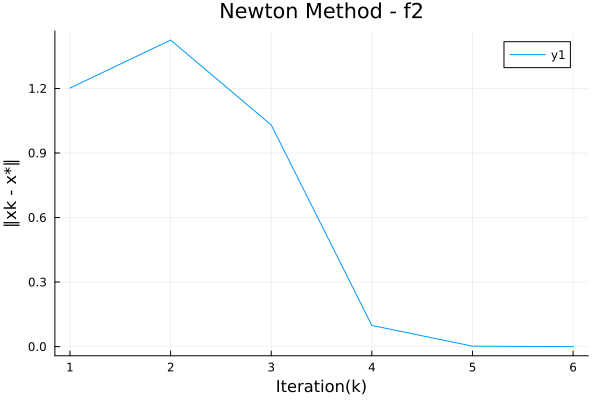

In [4]:
using Plots
include("../src/newton.jl") # votre algorithme de Newton
include("../test/fonctions_de_tests.jl") # pour avoir la fonction d'affichage des résultats

# Fonction f2
# -----------
f2(x) = 100 * (x[2] - x[1]^2)^2 + (1 - x[1])^2
grad_f2(x) = [-400 * x[1] * (x[2] - x[1]^2) - 2 * (1 - x[1]); # dérivée /x1
	200 * (x[2] - x[1]^2)] # dérivée /x2
hess_f2(x) = [          400*(3*x[1]^2-x[2])+2          -400*x[1]; # dérivée seconde /x1x1 and /x1x2
	-400*x[1]    200]                           # dérivée seconde /x2x1 and /x2x2
solution = [1; 1]

x0 = [0; 1/3]
x_sol, f_sol, flag, nb_iters, xs = newton(f2, grad_f2, hess_f2, x0)
afficher_resultats("Newton", "f2", x0, x_sol, f_sol, flag, nb_iters, solution)
norm_diff = [norm(x - solution) for x in xs]
plot(norm_diff, title = "Newton Method - f2", xlabel = "Iteration(k)", ylabel = "∥xk - x*∥")
